In [ ]:
# Cell 1: Install required libraries
!pip install ultralytics opencv-python-headless matplotlib lxml Pillow PyYAML

In [ ]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Set this to your dataset folder path inside Drive ──────────────────────────
DATASET_ROOT = "/content/drive/MyDrive/saudi_plates_dataset/License-Characters-by-2-27classes"  # ← change if needed

import os
print("📁 Files found:", len(os.listdir(DATASET_ROOT)))

In [12]:
# Cell 3: Imports
import os
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml

In [ ]:
# Cell 4: Parse ALL XML files to discover every unique character class
#
# KEY INSIGHT from your sample data:
#   - XML <name> tags contain the ACTUAL character: "0","4","6","J","A", etc.
#   - TXT class indices (0,4,6,10,16...) are arbitrary and may NOT match
#     the character value itself (e.g. index 16 = "J", index 10 = "A")
#   - We ALWAYS derive our class map from XML — never trust the raw TXT indices
#
# This cell builds a clean, consistent mapping: character_string → class_index

def build_class_map(dataset_root):
    """
    Scans all XML files to collect every unique <name> label.
    Returns:
        class_map   : dict  {character_string: new_class_index}
        class_names : list  [character_string, ...]  indexed by new_class_index
    """
    all_classes = set()
    xml_files   = list(Path(dataset_root).glob("*.xml"))

    if not xml_files:
        raise FileNotFoundError(f"No XML files found in: {dataset_root}")

    for xml_path in xml_files:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall("object"):
            label = obj.find("name").text.strip()
            all_classes.add(label)

    # Deterministic sort → digits first (0-9), then Latin letters, then Arabic
    sorted_classes = sorted(all_classes, key=lambda c: (
        0 if c.isdigit() else 1 if c.isascii() else 2, c
    ))

    class_map   = {name: idx for idx, name in enumerate(sorted_classes)}
    class_names = sorted_classes  # index → character name

    print(f"✅ Found {len(class_map)} unique character classes:")
    for idx, name in enumerate(class_names):
        print(f"   [{idx:2d}] '{name}'")

    return class_map, class_names


CLASS_MAP, CLASS_NAMES = build_class_map(DATASET_ROOT)

In [ ]:
# Cell 5: Regenerate YOLO .txt annotation files from XML
#
# WHY we do this instead of using the existing .txt files:
#   The original .txt files use the dataset author's arbitrary index scheme.
#   After Cell 4 we have OUR OWN consistent index scheme derived from XML.
#   We overwrite every .txt file so training indices match CLASS_NAMES exactly.
#
# YOLO format per line:
#   class_index  x_center  y_center  width  height   (all normalized 0-1)

def xml_to_yolo(xml_path, class_map):
    """
    Converts a single Pascal VOC XML annotation to YOLO-format lines.
    Uses CLASS_MAP built from XML <name> tags — not the original .txt indices.
    Returns list of strings ready to write to a .txt file.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size  = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    yolo_lines = []
    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        if label not in class_map:
            print(f"  ⚠️  Unknown label '{label}' in {xml_path.name} — skipping")
            continue

        class_idx = class_map[label]

        bndbox = obj.find("bndbox")
        xmin   = float(bndbox.find("xmin").text)
        ymin   = float(bndbox.find("ymin").text)
        xmax   = float(bndbox.find("xmax").text)
        ymax   = float(bndbox.find("ymax").text)

        # Normalize to 0-1 range (YOLO format)
        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width    = (xmax - xmin)       / img_w
        height   = (ymax - ymin)       / img_h

        yolo_lines.append(
            f"{class_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    return yolo_lines


# Overwrite all .txt files with our consistent class indices
converted, skipped = 0, 0
for xml_path in Path(DATASET_ROOT).glob("*.xml"):
    # Make sure a matching image exists before writing the annotation
    img_candidates = [
        xml_path.with_suffix(ext)
        for ext in [".jpeg", ".jpg", ".png", ".bmp"]
    ]
    if not any(p.exists() for p in img_candidates):
        skipped += 1
        continue

    lines    = xml_to_yolo(xml_path, CLASS_MAP)
    txt_path = xml_path.with_suffix(".txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    converted += 1

print(f"✅ Regenerated {converted} YOLO .txt files from XML")
if skipped:
    print(f"⚠️  Skipped {skipped} XML files (no matching image found)")


# Quick sanity check — print one regenerated file to verify
sample_txt = next(Path(DATASET_ROOT).glob("*.txt"))
print(f"\n📄 Sample regenerated .txt ({sample_txt.name}):")
print(sample_txt.read_text(encoding="utf-8"))

In [ ]:
# Cell 6: Split dataset 80% train / 10% val / 10% test
YOLO_DIR = "/content/yolo_plates"

for split in ["train", "val", "test"]:
    os.makedirs(f"{YOLO_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DIR}/labels/{split}", exist_ok=True)

# Collect images that have a matching regenerated annotation
image_extensions = {".jpeg", ".jpg", ".png", ".bmp"}
all_images = [
    p for p in Path(DATASET_ROOT).iterdir()
    if p.suffix.lower() in image_extensions
    and p.with_suffix(".txt").exists()
]

random.seed(42)
random.shuffle(all_images)

n       = len(all_images)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    "train": all_images[:n_train],
    "val":   all_images[n_train : n_train + n_val],
    "test":  all_images[n_train + n_val:]
}

for split, images in splits.items():
    for img_path in images:
        shutil.copy(img_path,                    f"{YOLO_DIR}/images/{split}/{img_path.name}")
        shutil.copy(img_path.with_suffix(".txt"), f"{YOLO_DIR}/labels/{split}/{img_path.stem}.txt")

print(f"✅ Dataset split complete:")
print(f"   Train : {len(splits['train'])} images")
print(f"   Val   : {len(splits['val'])} images")
print(f"   Test  : {len(splits['test'])} images")

In [ ]:
# Cell 7: Create the YAML config file YOLOv8 reads during training
data_yaml = {
    "path"  : YOLO_DIR,
    "train" : "images/train",
    "val"   : "images/val",
    "test"  : "images/test",
    "nc"    : len(CLASS_NAMES),
    "names" : CLASS_NAMES
}

yaml_path = f"{YOLO_DIR}/data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, allow_unicode=True, default_flow_style=False)

print(f"✅ data.yaml saved to: {yaml_path}")
print(f"   Total classes: {len(CLASS_NAMES)}")
print(f"   Class names  : {CLASS_NAMES}")

In [ ]:
# Cell 8: Train YOLOv8 nano on the Saudi plates dataset
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data      = yaml_path,
    epochs    = 100,
    imgsz     = 640,
    batch     = 16,
    name      = "saudi_plates_yolov8n",
    project   = "/content/runs",
    patience  = 20,
    augment   = True,
    lr0       = 0.01,
    lrf       = 0.01,
    cache     = True,
    verbose   = True
)

print("✅ Training complete!")
print("📁 Best weights: /content/runs/saudi_plates_yolov8n/weights/best.pt")

In [ ]:
# Cell 9: Visualize training curves
from IPython.display import Image as IPImage

results_img = "/content/runs/saudi_plates_yolov8n/results.png"
if os.path.exists(results_img):
    display(IPImage(results_img, width=900))
else:
    print("⚠️ Results image not found. Check /content/runs/")

In [ ]:
# Cell 10: Evaluate on the held-out test set
best_weights  = "/content/runs/saudi_plates_yolov8n/weights/best.pt"
trained_model = YOLO(best_weights)

metrics = trained_model.val(
    data  = yaml_path,
    split = "test",
    imgsz = 640,
    conf  = 0.4
)

print(f"\n📊 Test Set Evaluation:")
print(f"   mAP@50    : {metrics.box.map50:.4f}")
print(f"   mAP@50-95 : {metrics.box.map:.4f}")
print(f"   Precision : {metrics.box.mp:.4f}")
print(f"   Recall    : {metrics.box.mr:.4f}")

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,913 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 331.6±265.2 MB/s, size: 11.5 KB)
val: Scanning /content/yolo_plates/labels/test... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 1.6Kit/s 0.0s
val: New cache created: /content/yolo_plates/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s
                   all         60        395      0.941       0.85      0.837       0.64
                     0         17         20          1          1      0.995      0.726
                     1         13         14          1      0.927      0.925      0.717
                     2         17         17          1      0.824      0.825      0.647
                     3         26         26      0.926      0.962      0.938      0.

In [ ]:
# Cell 11: Full pipeline — plate image → detected characters → sorted text string

def read_plate(image_path, model, class_names, conf_threshold=0.4):
    """
    Full inference pipeline:
      1. YOLOv8 detects every character bounding box + class index
      2. Map class index → actual character via class_names list
      3. Sort detections left → right by x_center
      4. Concatenate characters → final plate string

    Args:
        image_path      : path to plate .jpeg image
        model           : loaded YOLO model
        class_names     : list where class_names[i] = character string
        conf_threshold  : minimum detection confidence to include

    Returns dict:
        plate_text   : e.g. "6046JAA"
        detections   : list of dicts per character (char, bbox, confidence)
        confidence   : average confidence across all detected characters
    """
    results = model(image_path, conf=conf_threshold, verbose=False)
    boxes   = results[0].boxes

    if boxes is None or len(boxes) == 0:
        return {"plate_text": "NOT DETECTED", "detections": [], "confidence": 0.0}

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        x_center  = (x1 + x2) / 2
        class_idx = int(box.cls[0].item())
        conf      = float(box.conf[0].item())
        char      = class_names[class_idx]   # ← maps index → actual character

        detections.append({
            "char"      : char,
            "x_center"  : x_center,
            "bbox"      : (x1, y1, x2, y2),
            "confidence": conf
        })

    # Sort left → right to reconstruct correct character order
    detections.sort(key=lambda d: d["x_center"])

    plate_text = "".join(d["char"] for d in detections)
    avg_conf   = float(np.mean([d["confidence"] for d in detections]))

    return {
        "plate_text" : plate_text,
        "detections" : detections,
        "confidence" : round(avg_conf, 3)
    }

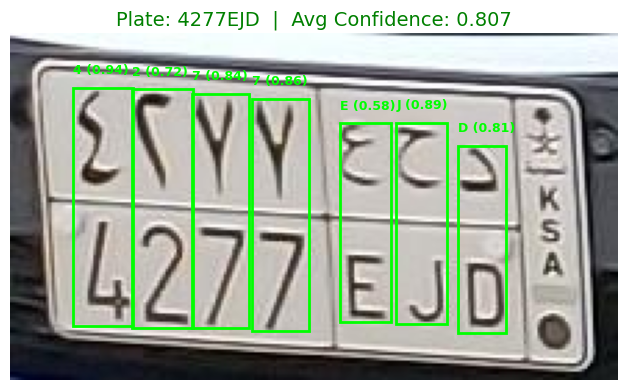

📋 Extracted Text  : 4277EJD
📊 Avg Confidence  : 0.807
🔢 Characters Found: 7


In [ ]:
# Cell 12: Draw bounding boxes + labels on a plate image
def visualize_plate(image_path, model, class_names, conf_threshold=0.4):
    result  = read_plate(image_path, model, class_names, conf_threshold)
    img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(12, 4))
    ax.imshow(img_rgb)

    for det in result["detections"]:
        x1, y1, x2, y2 = det["bbox"]
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        ))
        ax.text(x1, y1 - 5, f"{det['char']} ({det['confidence']:.2f})",
                color='lime', fontsize=9, fontweight='bold')

    color = 'green' if result['confidence'] > 0.6 else 'red'
    ax.set_title(
        f"Plate: {result['plate_text']}  |  Avg Confidence: {result['confidence']}",
        fontsize=14, color=color
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"📋 Extracted Text  : {result['plate_text']}")
    print(f"📊 Avg Confidence  : {result['confidence']}")
    print(f"🔢 Characters Found: {len(result['detections'])}")

# ── Usage ──────────────────────────────────────────────────────────────────────
sample_image = list(Path(f"{YOLO_DIR}/images/test").iterdir())[0]
visualize_plate(str(sample_image), trained_model, CLASS_NAMES)

In [ ]:
# Cell 13: Run full pipeline on all test images
def batch_inference(test_folder, model, class_names, conf_threshold=0.4):
    image_files = [
        f for f in Path(test_folder).iterdir()
        if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    all_results = []
    for img_path in image_files:
        result = read_plate(str(img_path), model, class_names, conf_threshold)
        all_results.append({
            "filename"  : img_path.name,
            "plate_text": result["plate_text"],
            "confidence": result["confidence"],
            "char_count": len(result["detections"])
        })
        print(f"✅ {img_path.name:40s} → {result['plate_text']:12s} (conf: {result['confidence']})")

    confs = [r["confidence"] for r in all_results if r["confidence"] > 0]
    print(f"\n{'='*65}")
    print(f"📊 Total processed      : {len(all_results)}")
    print(f"📈 Average confidence   : {np.mean(confs):.3f}")
    print(f"✅ High conf (>0.7)     : {sum(c > 0.7 for c in confs)}")
    print(f"⚠️  Low conf  (<0.4)     : {sum(c < 0.4 for c in confs)}")
    return all_results

all_results = batch_inference(f"{YOLO_DIR}/images/test", trained_model, CLASS_NAMES)

✅ ckie5wmvf004y246ayzjhtixf.jpeg           → 4277EJD      (conf: 0.807)
✅ ckj6z5tj8001a246arp393tnm.png            → 6507EGB      (conf: 0.761)
✅ ckj6z4c540019246asf2gccmr.png            → 2039         (conf: 0.62)
✅ ckj6v6ih2000x246ailzjomin.png            → 2039ZA       (conf: 0.855)
✅ ckiczgqqg001s246au2jc6frk.jpeg           → 3047JBB      (conf: 0.909)
✅ ckicxt0op000u246alg56ihkb.jpeg           → 5349LVJ      (conf: 0.9)
✅ ckifj4px2007w246aosgaphee.jpeg           → 1857DD       (conf: 0.806)
✅ ckie9t257007f246azz6y65h1.jpeg           → 294RD        (conf: 0.772)
✅ ckifkaw4q008s246alvvfpfyr.jpeg           → 563JLD       (conf: 0.694)
✅ ckj2qw36o0007246a3h90snn3.png            → 920XAJ       (conf: 0.728)
✅ ckn7ddopj01h63068h5v2q77y.jpeg           → 5655VB       (conf: 0.909)
✅ ckie9dfxq0076246arsmr3qby.jpeg           → 579B         (conf: 0.721)
✅ ckn7d0pi701c83068l3u59ybi.jpeg           → 4817TLD      (conf: 0.84)
✅ ckie9h3v90078246aewo9cszp.jpeg           → 7147VXA      (conf: 0.8

In [ ]:
# Cell 14: Export results to CSV
import csv

def save_results_csv(results, output_path="/content/plate_results.csv"):
    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["filename","plate_text","confidence","char_count"])
        writer.writeheader()
        writer.writerows(results)
    print(f"💾 Results saved to: {output_path}")

save_results_csv(all_results)

💾 Results saved to: /content/plate_results.csv


In [ ]:
# Cell 15: Persist weights to Drive before Colab session resets
DRIVE_SAVE_PATH = "/content/drive/MyDrive/saudi_plates_model"
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

shutil.copy("/content/runs/saudi_plates_yolov8n/weights/best.pt",
            f"{DRIVE_SAVE_PATH}/best.pt")
shutil.copy(yaml_path,
            f"{DRIVE_SAVE_PATH}/data.yaml")

with open(f"{DRIVE_SAVE_PATH}/class_names.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(CLASS_NAMES))

print(f"✅ Saved to Google Drive: {DRIVE_SAVE_PATH}/")
print(f"   - best.pt")
print(f"   - data.yaml")
print(f"   - class_names.txt")

✅ Saved to Google Drive: /content/drive/MyDrive/saudi_plates_model/
   - best.pt
   - data.yaml
   - class_names.txt
